<a href="https://colab.research.google.com/github/Nelman25/CCMACLRL_EXERCISES_COM231/blob/master/Exercise6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Exercise 6: Choosing the best performing model on a dataset

Instructions:

- Use the Dataset File to train your model
- Use the Test File to generate your results
- Use the Sample Submission file to generate the same format
- Use all Regression models

Submit your results to:
https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/overview



In [125]:
import pandas as pd
import seaborn as sns
import numpy as np

from matplotlib import pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import cross_val_score

## Dataset File

In [126]:
train_data = 'https://github.com/robitussin/CCMACLRL_EXERCISES/blob/3fd7d51ffd17863598ac3f44eeefc558171a5b73/dataset/house-prices-advanced-regression-techniques/train.csv?raw=true'
df = pd.read_csv(train_data)

## Test File

In [127]:
test_url = 'https://github.com/robitussin/CCMACLRL_EXERCISES/blob/3fd7d51ffd17863598ac3f44eeefc558171a5b73/dataset/house-prices-advanced-regression-techniques/test.csv?raw=true'
dt=pd.read_csv(test_url)

In [128]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

## Sample Submission File

In [129]:
sample_submission_url ='https://github.com/robitussin/CCMACLRL_EXERCISES/blob/3fd7d51ffd17863598ac3f44eeefc558171a5b73/dataset/house-prices-advanced-regression-techniques/sample_submission.csv?raw=true'

sf=pd.read_csv(sample_submission_url)

In [130]:
sf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Id         1459 non-null   int64  
 1   SalePrice  1459 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 22.9 KB


In [131]:
df.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [132]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [134]:
score_list = {}

In [135]:
label_encoder = LabelEncoder()

columns = df.columns

for column in columns:
  df[column] = label_encoder.fit_transform(df[column])


In [136]:
X =  df.drop(columns=["Id", "SalePrice"]).values
y = df["SalePrice"].values

In [137]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

## 1. Train a KNN Regressor

In [138]:
# put your answer here
KNN = KNeighborsRegressor(n_neighbors=20)

knn_model = KNN.fit(X_train, y_train)
knn_score = KNN.score(X_test, y_test)
score_list["KNN"] = knn_score

print(f"KNN Regressor score: {knn_score}")

KNN Regressor score: 0.7507675642294863


- Perform cross validation

In [139]:
# put your answer here
knn_scores = cross_val_score(knn_model, X, y, cv=5)

print(f"KNN scores: {knn_scores}")
print(f"KNN mean score: {knn_scores.mean()}")

KNN scores: [0.79305968 0.81062951 0.76398502 0.76367963 0.73192465]
KNN mean score: 0.772655697183912


## 2. Train a SVM Regression

In [140]:
# put your answer here
svr = SVR()

svr.fit(X_train, y_train)
svr_score = svr.score(X_test, y_test)
score_list["SVR"] = svr_score

print(f"SVR score: {svr_score}")

SVR score: 0.5117208889219467


- Perform cross validation

In [141]:
# put your answer here
svr_scores = cross_val_score(svr, X, y, cv=5)

print(f"SVR scores: {svr_scores}")
print(f"SVR mean score: {svr_scores.mean()}")

SVR scores: [0.53514663 0.52653811 0.49965283 0.5104301  0.50932979]
SVR mean score: 0.5162194936045308


## 3. Train a Decision Tree Regression

In [142]:
# put your answer here
dtr = DecisionTreeRegressor()

dtr.fit(X_train, y_train)
dtr_score = dtr.score(X_test, y_test)
score_list["Decision Tree Regressor"] = dtr_score

print(f"Decision Tree Regressor score: {dtr_score}")


Decision Tree Regressor score: 0.7816802912965494


- Perform cross validation

In [143]:
# put your answer here
dtr_scores = cross_val_score(dtr, X, y, cv=5)

print(f"Decision Tree Regressor scores: {dtr_scores}")
print(f"Decision Tree Regressor mean score: {dtr_scores.mean()}")

Decision Tree Regressor scores: [0.76559372 0.78166944 0.76045131 0.77547509 0.73396857]
Decision Tree Regressor mean score: 0.7634316244157442


## 4. Train a Random Forest Regression

In [144]:
# put your answer here
rfr = RandomForestRegressor()

rfr.fit(X_train, y_train)
rfr_score = rfr.score(X_test, y_test)
score_list["Random Forest Regressor"] = rfr_score

print(f"Random Forest Regressor score: {rfr_score}")

Random Forest Regressor score: 0.8891250978134524




*   Perform cross validation


In [145]:
rfr_scores = cross_val_score(rfr, X, y, cv=5)

print(f"Random Forest Regressor scores: {rfr_scores}")
print(f"Random Forest Regressor mean score: {rfr_scores.mean()}")

Random Forest Regressor scores: [0.89287107 0.90932683 0.88624387 0.90399571 0.86580769]
Random Forest Regressor mean score: 0.8916490362556091


### Extract the importance of each feature from our Random Forest Model


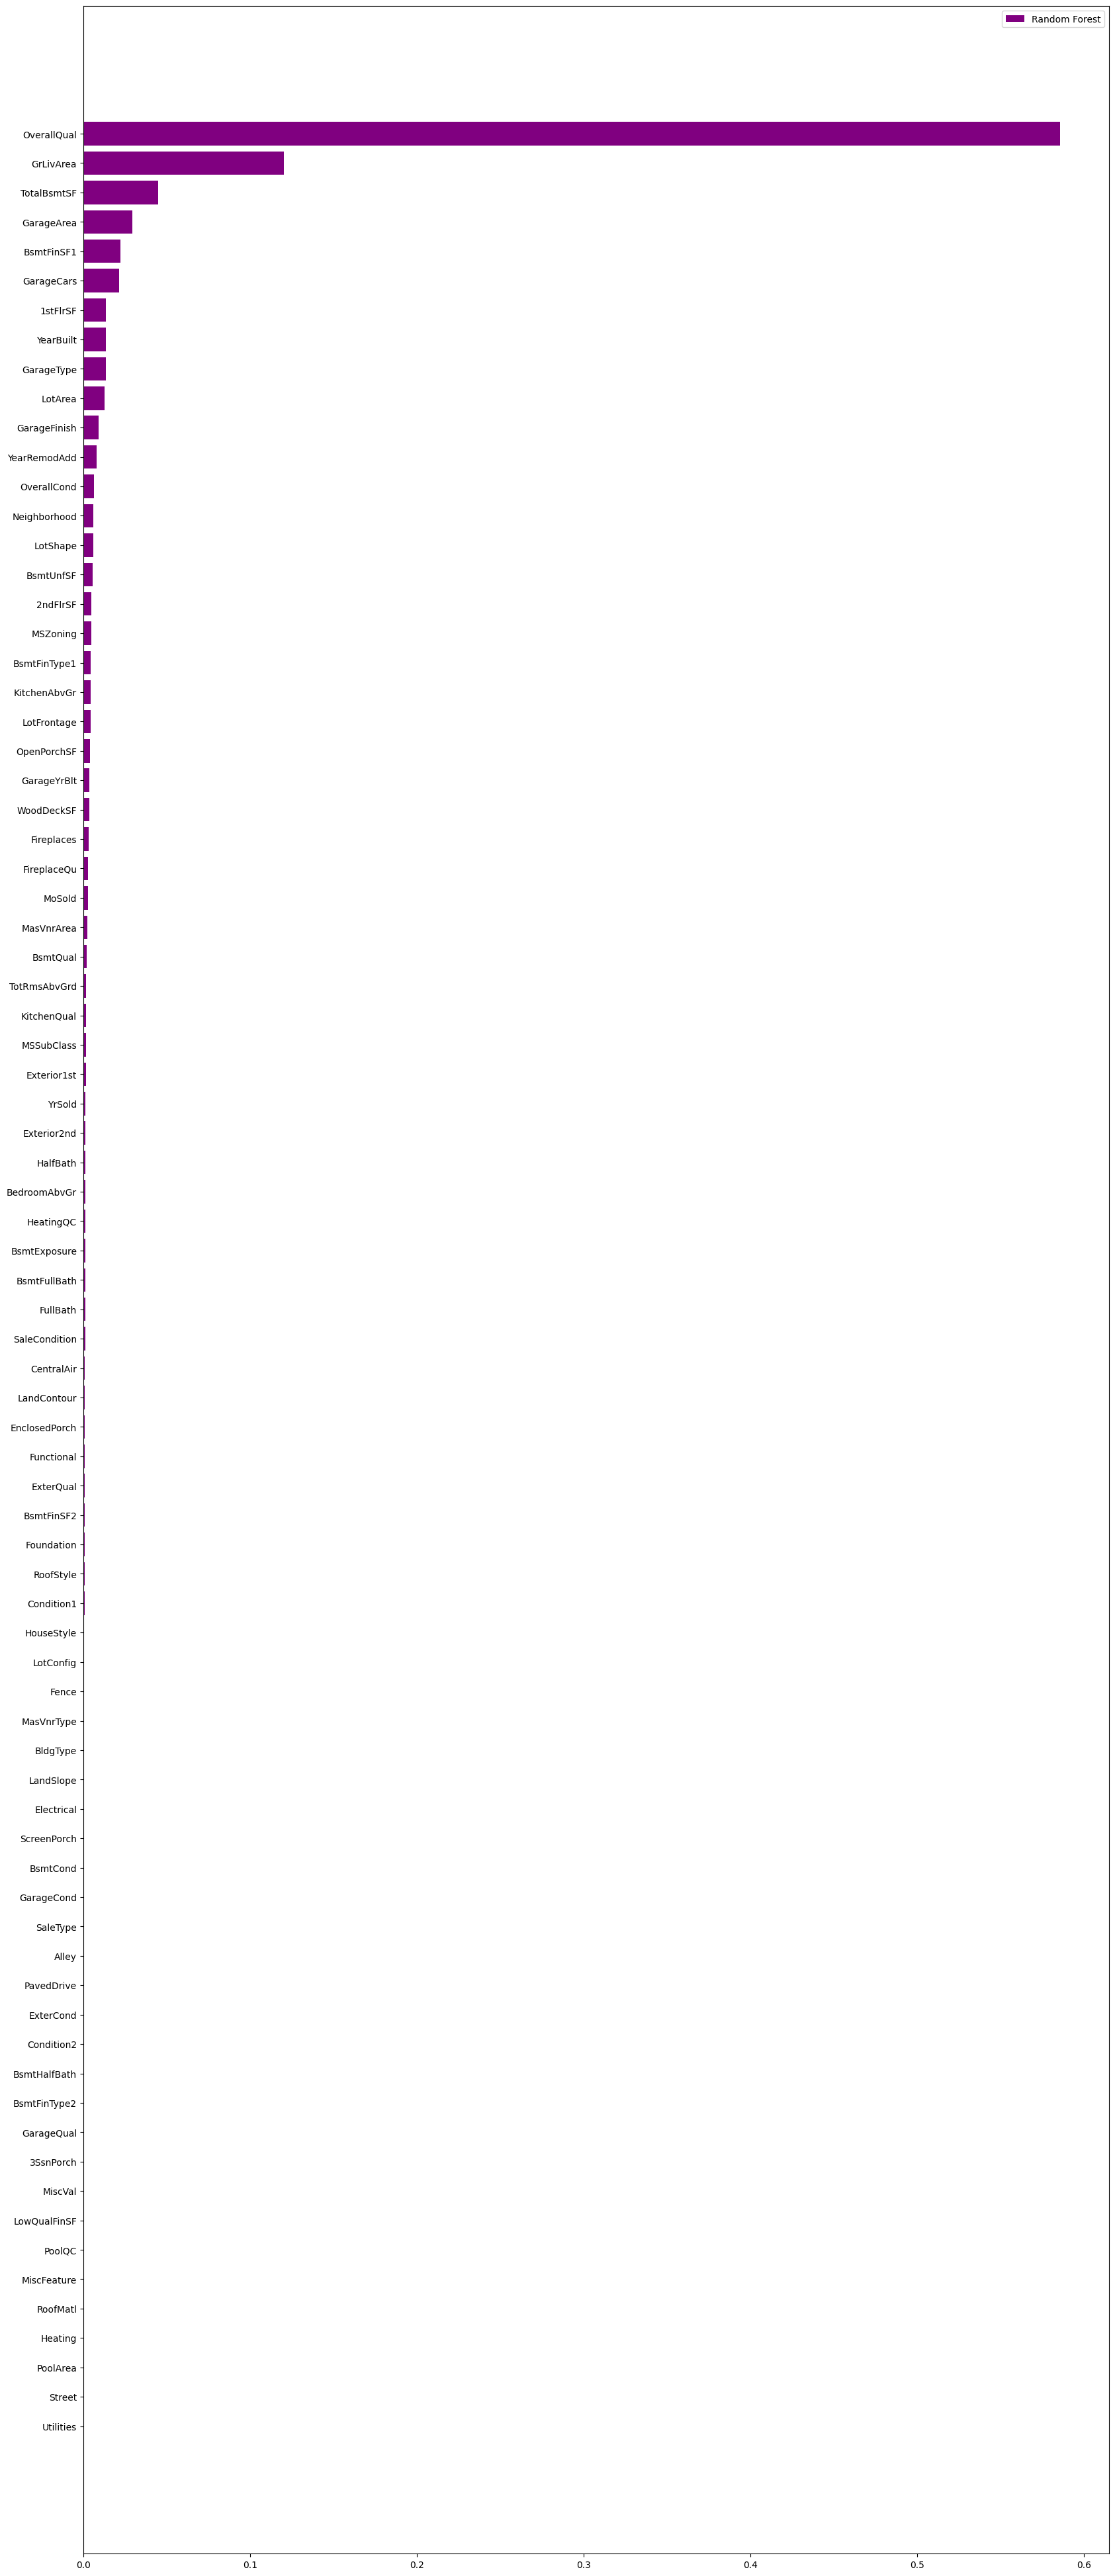

In [146]:
feature_importance = pd.DataFrame({'rfr':rfr.feature_importances_}, index = df.drop(columns = ['Id','SalePrice']).columns)

feature_importance.sort_values('rfr',ascending = True,inplace = True)

index = np.arange(len(feature_importance))
fig, ax = plt.subplots(figsize = (20,50))
rfr_feature = ax.barh(index, feature_importance['rfr'], color = 'purple', label = 'Random Forest')
ax.set(yticks = index , yticklabels = feature_importance.index)

ax.legend()
plt.show()


## 5. Compare all the performance of all regression models

---



In [147]:
# put your answer here
print("Model Performance Comparison:")
for model, score in score_list.items():
  print(f"{model}: {score}")

Model Performance Comparison:
KNN: 0.7507675642294863
SVR: 0.5117208889219467
Decision Tree Regressor: 0.7816802912965494
Random Forest Regressor: 0.8891250978134524


## 6. Generate Submission File

Choose the model that has the best performance to generate a submission file.

In [148]:
dt_columns = dt.columns

for column in dt_columns:
  dt[column] = label_encoder.fit_transform(dt[column])

dt.drop(columns=["Id"], inplace=True)
id = sf['Id']
y_pred = rfr.predict(dt)

submission_df = pd.DataFrame({
    'Id': id,
    'SalePrice': y_pred
})

submission_df.to_csv('submission_file.csv', index=False)
print("Submission file created: submission_file.csv")

Submission file created: submission_file.csv


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
